# LeetCode-Domain Threshold Distribution Check

This notebook uses only the official Task A **training split**, which represents the seen-language / seen-domain setting: C++, Python, Java algorithmic code.

Experiment design:
- sample **2000 LeetCode-domain training rows** to fit single and double thresholds
- sample **8 disjoint held-out subsets of 1000 rows** each to evaluate both strategies
- compute Fast-DetectGPT discrepancy scores for the fit subset and all held-out subsets
- compute the **average percentage improvement** of the double-threshold over the single-threshold across the 8 held-out sets
- plot score histograms with fitted normal curves for human and machine code

No official challenge test split is loaded or used.


## Environment Setup

We check if the notebook is running in Google Colab and install the necessary libraries (`transformers`, `datasets`, `accelerate`, etc.).

In [10]:
# Check environment and install dependencies
import os
import sys

IS_COLAB = "COLAB_GPU" in os.environ or "google.colab" in sys.modules
print(f"Running on {'Google Colab' if IS_COLAB else 'Local Machine'}")

if IS_COLAB:
    print("Installing requirements for Google Colab...")
    !pip install -q "datasets==4.3.0" "huggingface_hub>=0.34.0" transformers accelerate pandas pyarrow tqdm scikit-learn matplotlib seaborn torch
else:
    print("Local environment detected. Please ensure you have transformers, datasets, torch, pandas, scikit-learn, matplotlib, and seaborn installed.")


Running on Google Colab
Installing requirements for Google Colab...


## Configuration

Set the model, fixed sample sizes, and random seed for the train-only threshold experiment.


In [11]:
# Task A Configuration
DATASET_NAME = "DaniilOr/SemEval-2026-Task13"
DATASET_CONFIG = "A"
MODEL_NAME = "stabilityai/stable-code-3b"

# LeetCode-domain train-only experiment sizes.
THRESHOLD_FIT_SAMPLES = 2000
LEETCODE_TEST_SAMPLES = 1000
N_HOLDOUTS = 8  # Number of disjoint held-out subsets for averaging
THRESHOLD_GRID_SIZE = 200
MAX_LENGTH = 512
SEED = 99

import random
import numpy as np
import torch

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


## Load Tokenizer and Model

We load the causal language model with automatic precision setting (preferring `bfloat16` if supported by hardware, or `float16` as standard) to optimize memory consumption and speed.

In [12]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

print(f"Loading Tokenizer for {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Loading Model for {MODEL_NAME}...")
# Use float16 or bfloat16 to optimize memory and speed
torch_dtype = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float16

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch_dtype,
    device_map="auto" if device == "cuda" else None,
    trust_remote_code=True
)
model.eval()
print("Model loaded successfully!")

Using device: cuda
Loading Tokenizer for stabilityai/stable-code-3b...
Loading Model for stabilityai/stable-code-3b...


Loading weights:   0%|          | 0/356 [00:00<?, ?it/s]

Model loaded successfully!


## Fast-DetectGPT Score

Compute the analytic Fast-DetectGPT sampling discrepancy used by the threshold classifiers.


In [13]:
def get_sampling_discrepancy_analytic(logits_ref, logits_score, labels):
    assert logits_ref.shape[0] == 1
    assert logits_score.shape[0] == 1
    assert labels.shape[0] == 1

    if logits_ref.size(-1) != logits_score.size(-1):
        vocab_size = min(logits_ref.size(-1), logits_score.size(-1))
        logits_ref = logits_ref[:, :, :vocab_size]
        logits_score = logits_score[:, :, :vocab_size]

    labels = labels.unsqueeze(-1) if labels.ndim == logits_score.ndim - 1 else labels
    lprobs_score = torch.log_softmax(logits_score, dim=-1)
    probs_ref = torch.softmax(logits_ref, dim=-1)

    log_likelihood = lprobs_score.gather(dim=-1, index=labels).squeeze(-1)
    mean_ref = (probs_ref * lprobs_score).sum(dim=-1)
    var_ref = (probs_ref * torch.square(lprobs_score)).sum(dim=-1) - torch.square(mean_ref)

    discrepancy = (log_likelihood.sum(dim=-1) - mean_ref.sum(dim=-1)) / (var_ref.sum(dim=-1).sqrt() + 1e-8)
    return discrepancy.mean().item()


## Load Training Dataset

Only the official training split is loaded. The threshold-fitting and held-out evaluation subsets are sampled from this split without overlap.


In [14]:
import pandas as pd
from datasets import load_dataset

print(f"Loading official SemEval dataset '{DATASET_NAME}' (Task {DATASET_CONFIG}) training split...")
train_dataset = load_dataset(DATASET_NAME, DATASET_CONFIG, split="train")
train_df = train_dataset.to_pandas().dropna(subset=["code", "label"]).copy()
train_df["label"] = train_df["label"].astype(int)

print(f"Training dataset loaded: {len(train_df)} rows")
print("\nTraining label distribution:")
print(train_df["label"].value_counts().sort_index())
print("\nSample code snippet:")
print(train_df["code"].iloc[0][:300] + "...")


Loading official SemEval dataset 'DaniilOr/SemEval-2026-Task13' (Task A) training split...
Training dataset loaded: 500000 rows

Training label distribution:
label
0    238475
1    261525
Name: count, dtype: int64

Sample code snippet:
(a, b, c, d) = [int(x) for x in input().split()]
k = input()
(p, q, r, s) = (0, 0, 0, 0)
for i in k:
	if i == '1':
		p += 1
	elif i == '2':
		q += 1
	elif i == '3':
		r += 1
	elif i == '4':
		s += 1
print(a * p + b * q + c * r + d * s)
...


## Split LeetCode-Domain Rows and Compute Scores

Build one fixed stratified threshold-fitting subset (2000 rows) and **8 disjoint held-out subsets** (1000 rows each) from the official training split. Discrepancy scores are computed once for all subsets.


In [15]:
from tqdm.auto import tqdm


def make_stratified_fit_and_multiple_holdouts(df, fit_samples, test_samples, n_holdouts, seed):
    """Split df into one fit subset and n_holdouts disjoint test subsets.

    Each subset is balanced (50/50 per class).
    """
    if fit_samples % 2 != 0 or test_samples % 2 != 0:
        raise ValueError("fit_samples and test_samples must be even for balanced binary splits.")

    fit_per_class = fit_samples // 2
    test_per_class = test_samples // 2
    total_test_per_class = test_per_class * n_holdouts
    required_per_class = fit_per_class + total_test_per_class

    fit_parts = []
    holdout_pools = {0: None, 1: None}

    for label in [0, 1]:
        label_df = df[df["label"] == label].sample(frac=1.0, random_state=seed + label)
        if len(label_df) < required_per_class:
            raise ValueError(
                f"Not enough rows for label {label}: "
                f"need {required_per_class}, found {len(label_df)}"
            )
        fit_parts.append(label_df.iloc[:fit_per_class].copy())
        holdout_pools[label] = label_df.iloc[fit_per_class:required_per_class].copy()

    fit_df = pd.concat(fit_parts).sample(frac=1.0, random_state=seed).reset_index(drop=True)

    # Build n_holdouts disjoint test subsets
    holdout_dfs = []
    for h in range(n_holdouts):
        parts = []
        for label in [0, 1]:
            start = h * test_per_class
            end = start + test_per_class
            parts.append(holdout_pools[label].iloc[start:end].copy())
        holdout_df = pd.concat(parts).sample(
            frac=1.0, random_state=seed + 100 + h
        ).reset_index(drop=True)
        holdout_dfs.append(holdout_df)

    return fit_df, holdout_dfs


def compute_discrepancy_for_df(df, desc="Computing Discrepancy"):
    scores = []

    for row in tqdm(df.to_dict("records"), total=len(df), desc=desc):
        tokenized = tokenizer(
            row["code"],
            return_tensors="pt",
            truncation=True,
            max_length=MAX_LENGTH,
            return_token_type_ids=False,
        ).to(device)

        if tokenized.input_ids.shape[1] <= 5:
            scores.append(0.0)
            continue

        labels = tokenized.input_ids[:, 1:]

        with torch.no_grad():
            logits = model(**tokenized).logits[:, :-1]
            try:
                score = get_sampling_discrepancy_analytic(logits, logits, labels)
            except Exception:
                score = 0.0
            scores.append(score)

    scored_df = df.copy()
    scored_df["discrepancy_score"] = scores
    return scored_df


# --- Build fit + 8 held-out subsets ---
threshold_fit_source_df, holdout_source_dfs = make_stratified_fit_and_multiple_holdouts(
    train_df,
    fit_samples=THRESHOLD_FIT_SAMPLES,
    test_samples=LEETCODE_TEST_SAMPLES,
    n_holdouts=N_HOLDOUTS,
    seed=SEED,
)

print("Threshold fitting rows:")
print(threshold_fit_source_df["label"].value_counts().sort_index())
for i, hdf in enumerate(holdout_source_dfs):
    print(f"\nHeld-out subset {i+1} ({len(hdf)} rows):")
    print(hdf["label"].value_counts().sort_index())

# --- Score all subsets ---
fit_df = compute_discrepancy_for_df(
    threshold_fit_source_df,
    desc=f"Scoring {THRESHOLD_FIT_SAMPLES} threshold-fit LeetCode rows",
)

holdout_scored_dfs = []
for i, hdf in enumerate(holdout_source_dfs):
    scored = compute_discrepancy_for_df(
        hdf,
        desc=f"Scoring held-out subset {i+1}/{N_HOLDOUTS} ({len(hdf)} rows)",
    )
    holdout_scored_dfs.append(scored)
    print(f"Held-out subset {i+1} scored.")


Threshold fitting rows:
label
0    1000
1    1000
Name: count, dtype: int64

Held-out subset 1 (1000 rows):
label
0    500
1    500
Name: count, dtype: int64

Held-out subset 2 (1000 rows):
label
0    500
1    500
Name: count, dtype: int64

Held-out subset 3 (1000 rows):
label
0    500
1    500
Name: count, dtype: int64

Held-out subset 4 (1000 rows):
label
0    500
1    500
Name: count, dtype: int64

Held-out subset 5 (1000 rows):
label
0    500
1    500
Name: count, dtype: int64

Held-out subset 6 (1000 rows):
label
0    500
1    500
Name: count, dtype: int64

Held-out subset 7 (1000 rows):
label
0    500
1    500
Name: count, dtype: int64

Held-out subset 8 (1000 rows):
label
0    500
1    500
Name: count, dtype: int64


Scoring 2000 threshold-fit LeetCode rows:   0%|          | 0/2000 [00:00<?, ?it/s]

Scoring held-out subset 1/8 (1000 rows):   0%|          | 0/1000 [00:00<?, ?it/s]

Held-out subset 1 scored.


Scoring held-out subset 2/8 (1000 rows):   0%|          | 0/1000 [00:00<?, ?it/s]

...

Held-out subset 6 scored.


Scoring held-out subset 7/8 (1000 rows):   0%|          | 0/1000 [00:00<?, ?it/s]

Held-out subset 7 scored.


Scoring held-out subset 8/8 (1000 rows):   0%|          | 0/1000 [00:00<?, ?it/s]

Held-out subset 8 scored.


## Fit Thresholds and Evaluate on 8 Held-Out Subsets

Fit single and double thresholds on the 2000-row subset, then evaluate both strategies on each of the 8 disjoint 1000-row held-out subsets. The **average percentage improvement** of double-threshold over single-threshold is reported.


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, classification_report


def fit_single_threshold(y_true, y_scores, grid_size):
    thresholds = np.linspace(np.min(y_scores), np.max(y_scores), grid_size)
    best_threshold = thresholds[0]
    best_f1 = -1.0

    for threshold in thresholds:
        preds = (y_scores > threshold).astype(int)
        f1 = f1_score(y_true, preds, average="macro")
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold

    return best_threshold, best_f1, thresholds


def fit_double_threshold(y_true, y_scores, thresholds, single_threshold, single_f1):
    best_lower = np.min(y_scores)
    best_upper = single_threshold
    best_f1 = single_f1

    for upper in thresholds:
        for lower in thresholds:
            if lower >= upper:
                continue
            preds = ((y_scores < lower) | (y_scores > upper)).astype(int)
            f1 = f1_score(y_true, preds, average="macro")
            if f1 > best_f1:
                best_f1 = f1
                best_lower = lower
                best_upper = upper

    return best_lower, best_upper, best_f1


def predict_single(scores, threshold):
    return (scores > threshold).astype(int)


def predict_double(scores, lower, upper):
    return ((scores < lower) | (scores > upper)).astype(int)


# --- Fit thresholds on the 2000-row subset ---
fit_y = fit_df["label"].astype(int).values
fit_scores = fit_df["discrepancy_score"].values

best_single_threshold, fit_single_f1, threshold_grid = fit_single_threshold(
    fit_y, fit_scores, THRESHOLD_GRID_SIZE,
)
best_double_lower, best_double_upper, fit_double_f1 = fit_double_threshold(
    fit_y, fit_scores, threshold_grid, best_single_threshold, fit_single_f1,
)

print(f"Single threshold fitted on {THRESHOLD_FIT_SAMPLES} rows: {best_single_threshold:.4f}")
print(f"Double threshold fitted on {THRESHOLD_FIT_SAMPLES} rows: lower={best_double_lower:.4f}, upper={best_double_upper:.4f}")
print(f"Fit Macro F1: single={fit_single_f1:.4f}, double={fit_double_f1:.4f}")
print()

# --- Evaluate on each held-out subset ---
holdout_results = []

for i, hdf in enumerate(holdout_scored_dfs):
    test_y = hdf["label"].astype(int).values
    test_scores = hdf["discrepancy_score"].values
    single_preds = predict_single(test_scores, best_single_threshold)
    double_preds = predict_double(test_scores, best_double_lower, best_double_upper)
    single_f1 = f1_score(test_y, single_preds, average="macro")
    double_f1 = f1_score(test_y, double_preds, average="macro")
    delta = double_f1 - single_f1
    pct_improvement = (delta / single_f1 * 100) if single_f1 > 0 else float('nan')

    holdout_results.append({
        "holdout": i + 1,
        "single_f1": single_f1,
        "double_f1": double_f1,
        "delta": delta,
        "pct_improvement": pct_improvement,
    })

    print(f"--- Held-out subset {i+1}/{N_HOLDOUTS} ---")
    print(f"  Single threshold Macro F1: {single_f1:.4f}")
    print(f"  Double threshold Macro F1: {double_f1:.4f}")
    print(f"  Delta (double - single):   {delta:+.4f}")
    print(f"  % Improvement:             {pct_improvement:+.2f}%")

    # Classification reports
    print(f"\n  Classification report: SINGLE threshold")
    print(classification_report(test_y, single_preds, target_names=["human", "machine"]))
    print(f"  Classification report: DOUBLE threshold")
    print(classification_report(test_y, double_preds, target_names=["human", "machine"]))
    print()

# --- Summary table ---
import pandas as pd

results_df = pd.DataFrame(holdout_results)
avg_single_f1 = results_df['single_f1'].mean()
avg_double_f1 = results_df['double_f1'].mean()
avg_delta = results_df['delta'].mean()
avg_pct = results_df['pct_improvement'].mean()

print("=" * 60)
print("SUMMARY ACROSS ALL HELD-OUT SUBSETS")
print("=" * 60)
display(results_df.style.format({
    'single_f1': '{:.4f}',
    'double_f1': '{:.4f}',
    'delta': '{:+.4f}',
    'pct_improvement': '{:+.2f}%',
}))
print(f"\nAverage Single Macro F1:  {avg_single_f1:.4f}")
print(f"Average Double Macro F1:  {avg_double_f1:.4f}")
print(f"Average Delta:            {avg_delta:+.4f}")
print(f"Average % Improvement:    {avg_pct:+.2f}%")


Single threshold fitted on 2000 rows: 0.9874
Double threshold fitted on 2000 rows: lower=-0.8687, upper=1.5443
Fit Macro F1: single=0.5536, double=0.6543

--- Held-out subset 1/8 ---
  Single threshold Macro F1: 0.5326
  Double threshold Macro F1: 0.6217
  Delta (double - single):   +0.0892
  % Improvement:             +16.74%

  Classification report: SINGLE threshold
              precision    recall  f1-score   support

       human       0.54      0.77      0.63       500
     machine       0.59      0.34      0.43       500

    accuracy                           0.55      1000
   macro avg       0.57      0.55      0.53      1000
weighted avg       0.57      0.55      0.53      1000

  Classification report: DOUBLE threshold
              precision    recall  f1-score   support

       human       0.60      0.73      0.66       500
     machine       0.66      0.52      0.58       500

    accuracy                           0.63      1000
   macro avg       0.63      0.63      0.

,holdout,single_f1,double_f1,delta,pct_improvement
0,1,0.5326,0.6217,+0.0892,+16.74%
1,2,0.5027,0.6552,+0.1525,+30.35%
2,3,0.5168,0.6428,+0.1259,+24.37%
3,4,0.5211,0.6227,+0.1016,+19.49%
4,5,0.5417,0.6356,+0.0939,+17.34%
5,6,0.5338,0.6299,+0.0962,+18.02%
6,7,0.5391,0.6485,+0.1094,+20.29%
7,8,0.5209,0.6827,+0.1618,+31.07%



Average Single Macro F1:  0.5261
Average Double Macro F1:  0.6424
Average Delta:            +0.1163
Average % Improvement:    +22.21%


## Normal Distribution Plots

These plots show discrepancy-score histograms with fitted normal curves for human and machine samples across the threshold-fitting subset and all 8 held-out subsets. The fitted single and double thresholds are drawn as vertical reference lines.


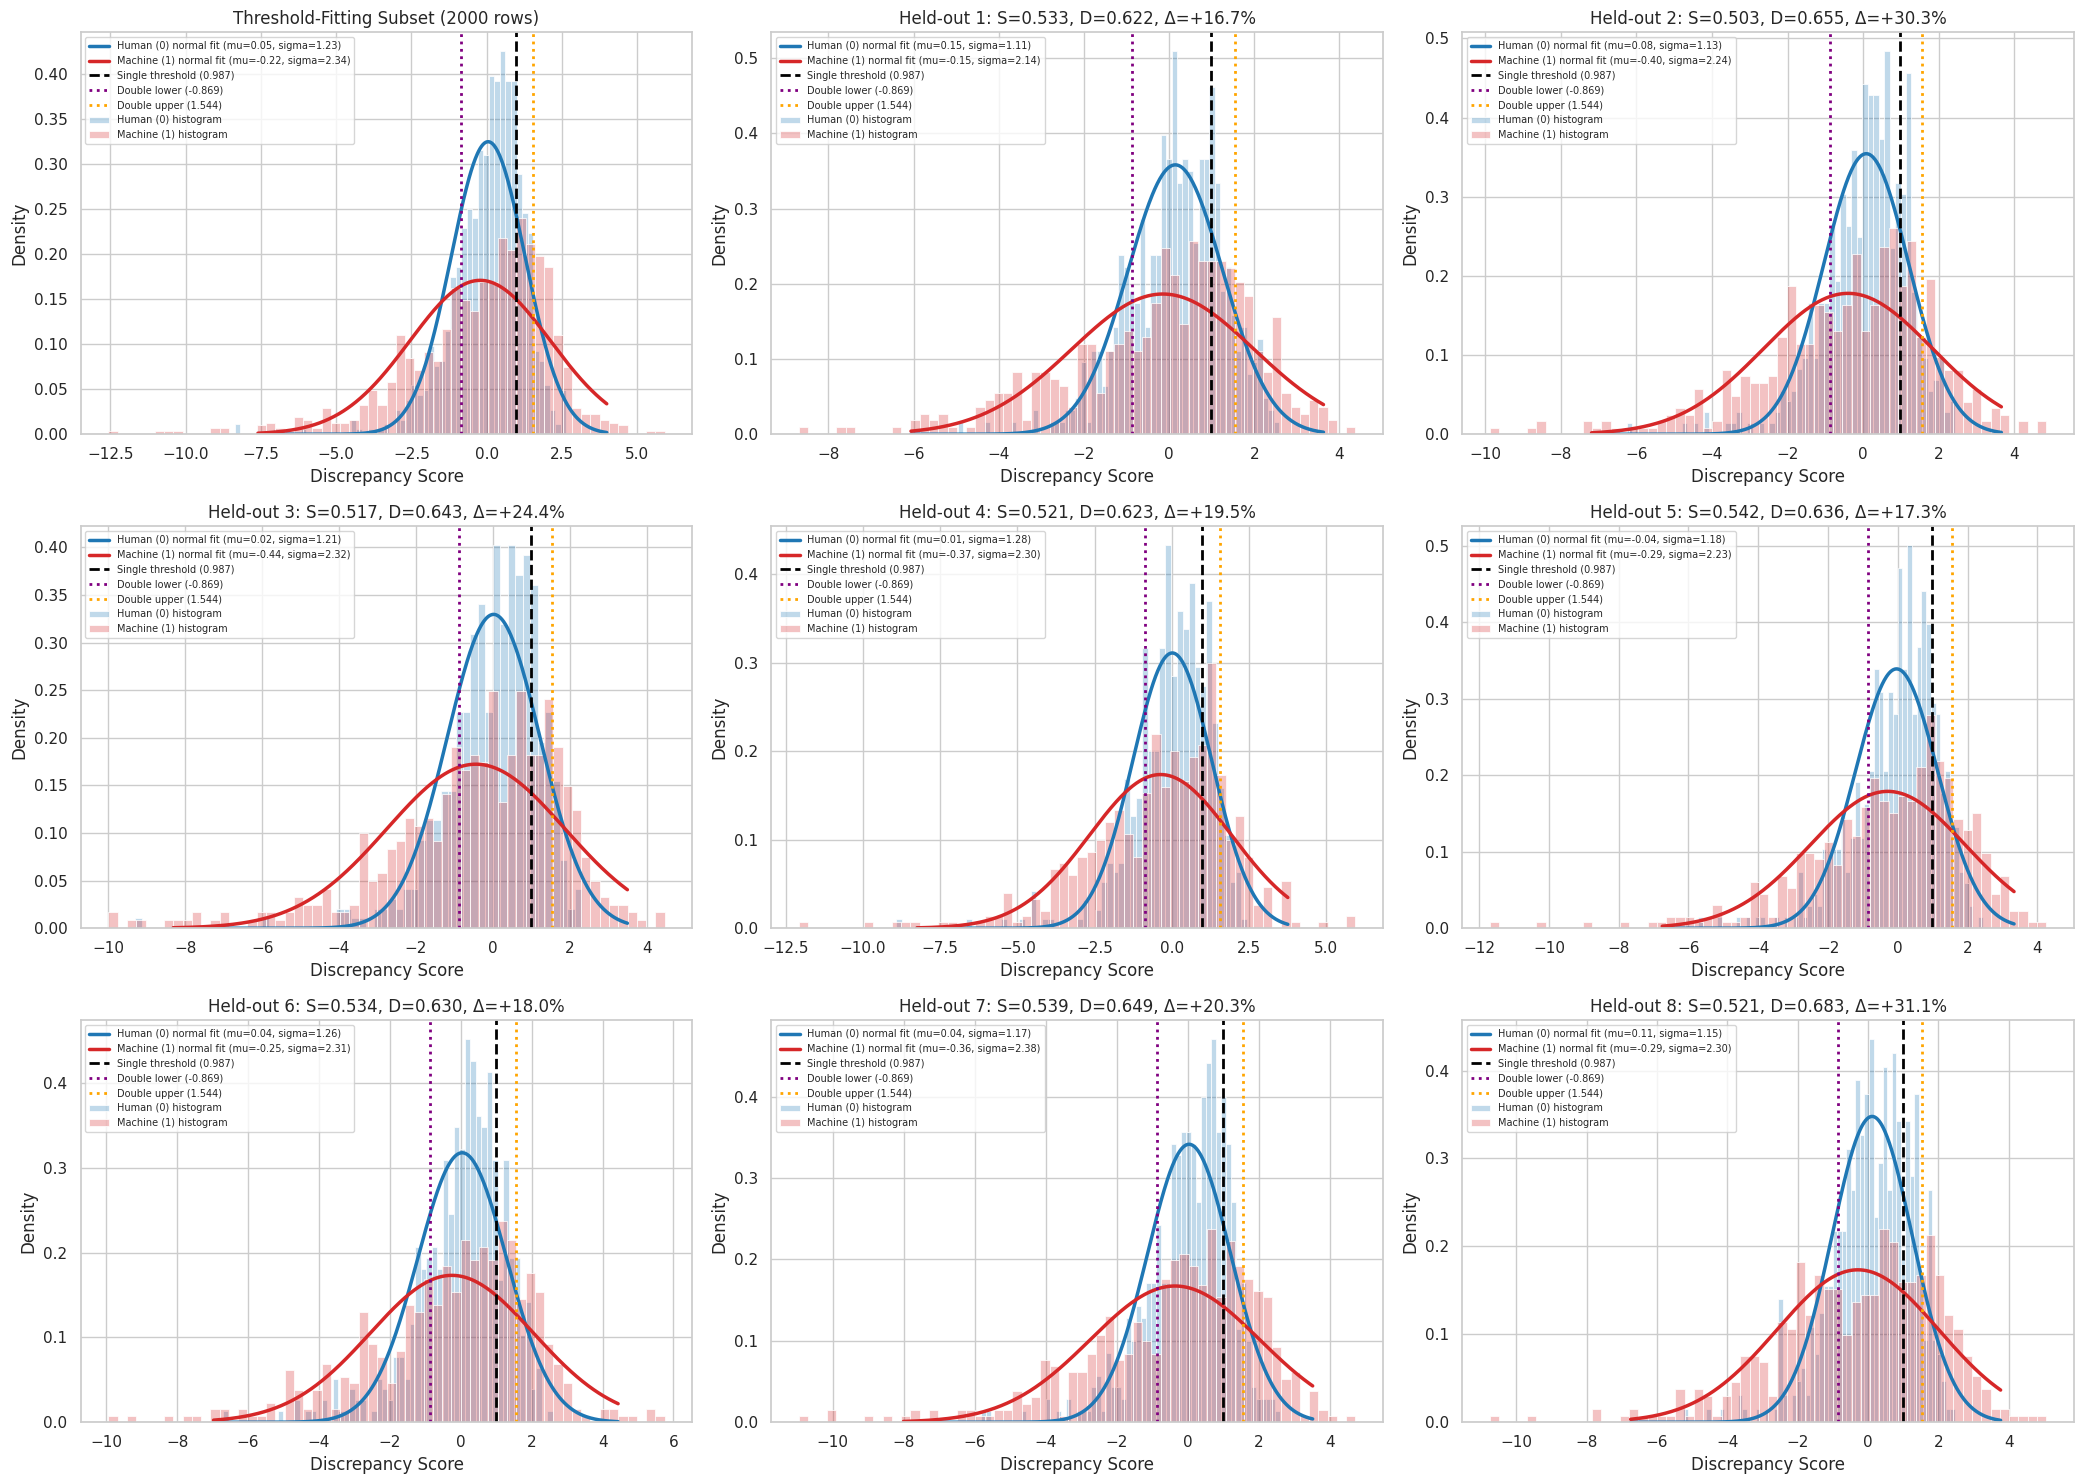

In [17]:
sns.set_theme(style="whitegrid")


def normal_pdf(x, mean, std):
    if std <= 0:
        return np.zeros_like(x)
    return np.exp(-0.5 * ((x - mean) / std) ** 2) / (std * np.sqrt(2 * np.pi))


def plot_normal_distribution(ax, plot_df, title):
    colors = {0: "#1f77b4", 1: "#d62728"}
    names = {0: "Human (0)", 1: "Machine (1)"}
    all_scores = plot_df["discrepancy_score"].dropna().values
    x_min, x_max = np.percentile(all_scores, [0.5, 99.5])
    x_grid = np.linspace(x_min, x_max, 500)

    for label in [0, 1]:
        scores = plot_df[plot_df["label"] == label]["discrepancy_score"].dropna().values
        mean = np.mean(scores)
        std = np.std(scores, ddof=1)
        sns.histplot(
            scores,
            color=colors[label],
            label=f"{names[label]} histogram",
            stat="density",
            bins=60,
            alpha=0.28,
            ax=ax,
        )
        ax.plot(
            x_grid,
            normal_pdf(x_grid, mean, std),
            color=colors[label],
            linewidth=2.5,
            label=f"{names[label]} normal fit (mu={mean:.2f}, sigma={std:.2f})",
        )

    ax.axvline(best_single_threshold, color="black", linestyle="--", linewidth=2,
              label=f"Single threshold ({best_single_threshold:.3f})")
    ax.axvline(best_double_lower, color="purple", linestyle=":", linewidth=2,
              label=f"Double lower ({best_double_lower:.3f})")
    ax.axvline(best_double_upper, color="orange", linestyle=":", linewidth=2,
              label=f"Double upper ({best_double_upper:.3f})")
    ax.set_title(title)
    ax.set_xlabel("Discrepancy Score")
    ax.set_ylabel("Density")
    ax.legend(fontsize=7)


# --- One figure with subplots: 1 fit + N_HOLDOUTS held-outs ---
n_plots = 1 + N_HOLDOUTS
n_cols = 3
n_rows = (n_plots + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 5 * n_rows))
axes = axes.flatten()

# Plot threshold-fitting subset
plot_normal_distribution(axes[0], fit_df, "Threshold-Fitting Subset (2000 rows)")

# Plot each held-out subset
for i, hdf in enumerate(holdout_scored_dfs):
    r = holdout_results[i]
    title = (
        f"Held-out {i+1}: S={r['single_f1']:.3f}, "
        f"D={r['double_f1']:.3f}, "
        f"Δ={r['pct_improvement']:+.1f}%"
    )
    plot_normal_distribution(axes[i + 1], hdf, title)

# Hide unused axes
for j in range(n_plots, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


## Summary: Single vs Double Threshold Comparison

A single bar chart comparing Macro F1 for single-threshold and double-threshold strategies across all 8 held-out subsets, with the average percentage improvement annotated.


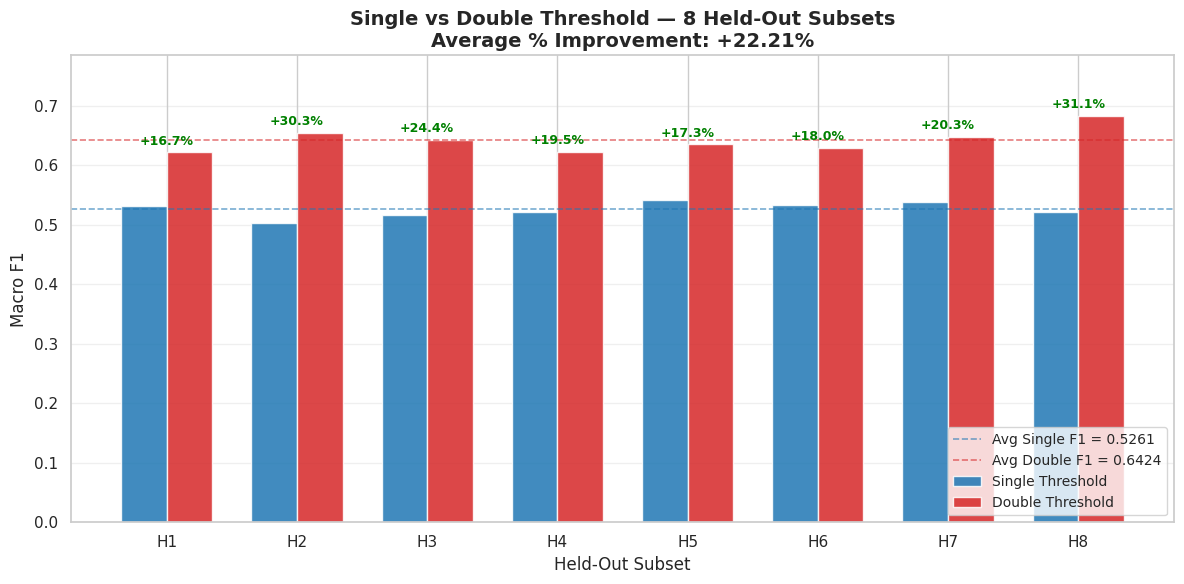

In [18]:
fig, ax = plt.subplots(figsize=(12, 6))

holdout_ids = [r['holdout'] for r in holdout_results]
single_f1s = [r['single_f1'] for r in holdout_results]
double_f1s = [r['double_f1'] for r in holdout_results]
pct_improvements = [r['pct_improvement'] for r in holdout_results]

x = np.arange(len(holdout_ids))
bar_width = 0.35

bars_single = ax.bar(x - bar_width / 2, single_f1s, bar_width,
                     label='Single Threshold', color='#1f77b4', alpha=0.85, edgecolor='white')
bars_double = ax.bar(x + bar_width / 2, double_f1s, bar_width,
                     label='Double Threshold', color='#d62728', alpha=0.85, edgecolor='white')

# Annotate % improvement on top of each pair
for i, (s, d, pct) in enumerate(zip(single_f1s, double_f1s, pct_improvements)):
    top = max(s, d)
    color = 'green' if pct > 0 else 'red'
    ax.text(i, top + 0.008, f'{pct:+.1f}%', ha='center', va='bottom',
            fontsize=9, fontweight='bold', color=color)

# Average line
ax.axhline(avg_single_f1, color='#1f77b4', linestyle='--', linewidth=1.2, alpha=0.6,
           label=f'Avg Single F1 = {avg_single_f1:.4f}')
ax.axhline(avg_double_f1, color='#d62728', linestyle='--', linewidth=1.2, alpha=0.6,
           label=f'Avg Double F1 = {avg_double_f1:.4f}')

ax.set_xlabel('Held-Out Subset', fontsize=12)
ax.set_ylabel('Macro F1', fontsize=12)
ax.set_title(
    f'Single vs Double Threshold — {N_HOLDOUTS} Held-Out Subsets\n'
    f'Average % Improvement: {avg_pct:+.2f}%',
    fontsize=14, fontweight='bold',
)
ax.set_xticks(x)
ax.set_xticklabels([f'H{h}' for h in holdout_ids])
ax.set_ylim(0, max(max(single_f1s), max(double_f1s)) * 1.15)
ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## High-Resolution Distribution Plot (Single Held-Out)

A single large plot of the discrepancy score distribution for one held-out subset, for higher visual clarity. Change `PLOT_HOLDOUT_INDEX` below to select a different subset (0–7).


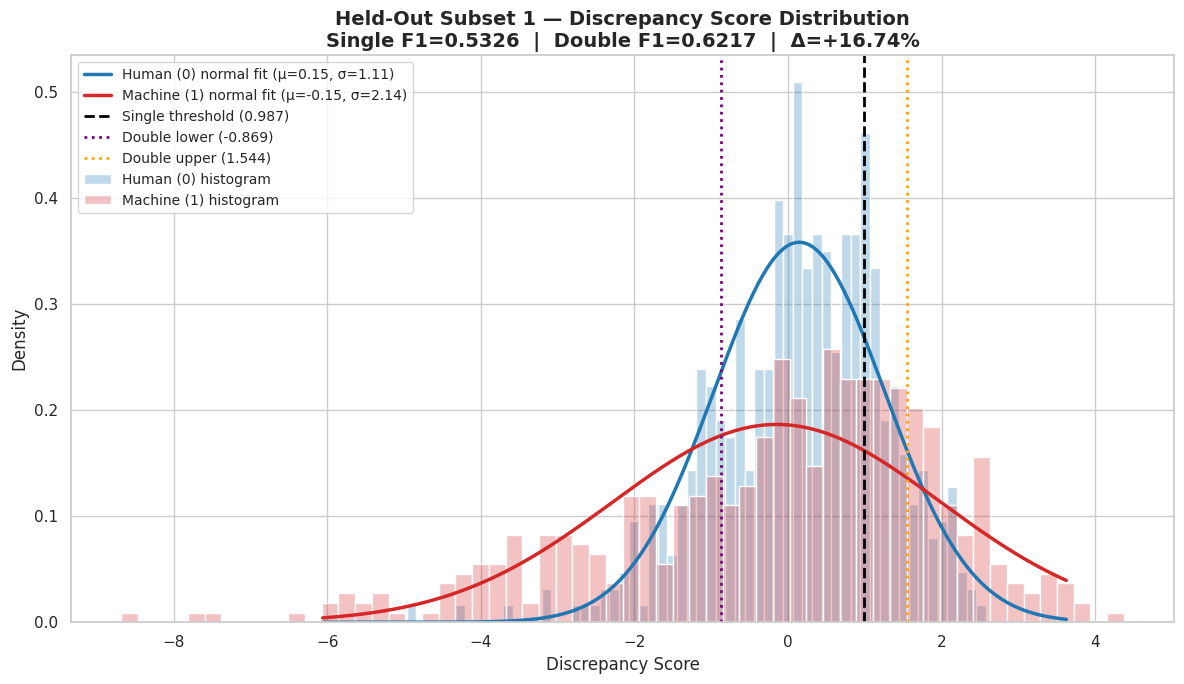

In [19]:
# --- Choose which held-out to plot (0-indexed) ---
PLOT_HOLDOUT_INDEX = 0

hdf = holdout_scored_dfs[PLOT_HOLDOUT_INDEX]
r = holdout_results[PLOT_HOLDOUT_INDEX]

fig, ax = plt.subplots(figsize=(12, 7))

colors = {0: '#1f77b4', 1: '#d62728'}
names = {0: 'Human (0)', 1: 'Machine (1)'}
all_scores = hdf['discrepancy_score'].dropna().values
x_min, x_max = np.percentile(all_scores, [0.5, 99.5])
x_grid = np.linspace(x_min, x_max, 500)

for label in [0, 1]:
    scores = hdf[hdf['label'] == label]['discrepancy_score'].dropna().values
    mean = np.mean(scores)
    std = np.std(scores, ddof=1)
    sns.histplot(
        scores,
        color=colors[label],
        label=f'{names[label]} histogram',
        stat='density',
        bins=60,
        alpha=0.28,
        ax=ax,
    )
    ax.plot(
        x_grid,
        normal_pdf(x_grid, mean, std),
        color=colors[label],
        linewidth=2.5,
        label=f'{names[label]} normal fit (μ={mean:.2f}, σ={std:.2f})',
    )

ax.axvline(best_single_threshold, color='black', linestyle='--', linewidth=2,
           label=f'Single threshold ({best_single_threshold:.3f})')
ax.axvline(best_double_lower, color='purple', linestyle=':', linewidth=2,
           label=f'Double lower ({best_double_lower:.3f})')
ax.axvline(best_double_upper, color='orange', linestyle=':', linewidth=2,
           label=f'Double upper ({best_double_upper:.3f})')

ax.set_title(
    f"Held-Out Subset {r['holdout']} — Discrepancy Score Distribution\n"
    f"Single F1={r['single_f1']:.4f}  |  Double F1={r['double_f1']:.4f}  |  "
    f"Δ={r['pct_improvement']:+.2f}%",
    fontsize=14, fontweight='bold',
)
ax.set_xlabel('Discrepancy Score', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()
